<div style="text-align: center; margin-bottom: 40px; margin-top: 0;">
    <img src="./pics/sage-logo.jpg" alt="SAGE Logo" style="width: 200px; margin-top: 20px;">
    <img src="./pics/ndp-logo.png" alt="NDP Logo" style="width: 130px; height: 100px; margin-top: 20px; margin-left: 100px;">
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">Exploring a week of Sage Sensor Data</h1>

## Why Relative Humidity Falls When Temperature Rises?
In this notebook, we will use live measurements from the Sage sensor network to explore one of the most fundamental relationships in meteorology: **as air warms, its relative humidity falls, even when the actual amount of water vapor in the air barely changes.**

We'll pull one week of data from node [**W06C**](https://portal.sagecontinuum.org/nodes/W06C), whose BME680 (a Bosch chip that measures temperature, humidity, pressure, and gas) reports both `env.temperature` and `env.relative_humidity`.

**What we'll do**

1. Query a week of data with [`sage_data_client`](https://pypi.org/project/sage-data-client/)
2. Reshape it, convert the temperatures to °F, and lightly clean it
3. Visualize how the two variables mirror each other over the daily cycle
4. Quantify the anti-correlation
5. Explain *why* with a little physics: saturation vapor pressure and dew point

## 0. Setup

Before starting our analysis, we'll first import the necessary libraries. Prior to this step, make sure you've installed the dependencies listed in `requirements.txt` using the extension button.

In [1]:
import folium
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sage_data_client

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Locating the Node

The node we'll be working with is located near Jackson Lake, Wyoming. Let's do a quick mapping exercise to pinpoint its location.

In [2]:
lat, lon = 43.940154336, -110.644136675 # These coordinates can be seen in the sage portal

m = folium.Map(location=[lat, lon], zoom_start=12)
folium.Marker([lat, lon], popup="My Point").add_to(m)

m  # displaying the map

## 2. Query one week of data

`sage_data_client.query()` takes a time range plus a dictionary of filters and returns a tidy pandas DataFrame. We will apply a filter to only return the values that we're interested in. 

| column:"value"| meaning |
|---|---|
| `vsn: "W06C"` | which node we want (its ID) |
| `name: "env.temperature\|env.relative_humidity"` | measurement names — the `\|` acts as an OR (it's a regex) |
| `sensor: "bme680"` | only readings from the BME680 chip |

- The names of the values representing temperature and relative humidity were obtained from the `info` pop-up on the sensor's Sage page.
- `start="-7d"` means "from 7 days ago until now". All timestamps come back in **UTC**.

In [3]:
df = sage_data_client.query(
    start="-7d",
    filter={
        "vsn": "W06C",
        "name": "env.temperature|env.relative_humidity",
        "sensor": "bme680",
    },
)

assert len(df) > 0, "No data returned — the node may have been offline. Try start='-30d' or another vsn."

print(f"Retrieved {len(df):,} records, "
      f"{df.timestamp.min():%Y-%m-%d %H:%M} to {df.timestamp.max():%Y-%m-%d %H:%M} UTC")
df.head()

Retrieved 40,290 records, 2026-07-09 18:20 to 2026-07-16 18:19 UTC


,timestamp,name,value,meta.host,meta.job,meta.node,meta.plugin,meta.sensor,meta.task,meta.vsn,meta.zone
0,2026-07-09 18:20:18.455218558+00:00,env.relative_humidity,43.455,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield
1,2026-07-09 18:20:48.485094704+00:00,env.relative_humidity,44.385,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield
2,2026-07-09 18:21:18.512053313+00:00,env.relative_humidity,42.655,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield
3,2026-07-09 18:21:48.542514395+00:00,env.relative_humidity,44.833,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield
4,2026-07-09 18:22:18.570662779+00:00,env.relative_humidity,44.659,0000dca632ed6eb6.ws-rpi,Pluginctl,000048b02d3ae335,waggle/plugin-iio:0.7.0,bme680,wes-iio-bme680,W06C,shield


Each row is a single measurement in *long* (tidy) format: a `timestamp`, the measurement `name`, its `value`, plus `meta.*` columns describing where it came from. 

We will do a quick sanity check on the ranges. The sensor reports temperature in °C (we'll convert to °F in the next step) and humidity should sit within 0–100 %:

In [4]:
df.groupby("name")["value"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
env.relative_humidity,20145.0,53.89,22.59,12.64,33.61,55.35,71.76,96.09
env.temperature,20145.0,20.68,7.82,7.92,14.42,18.96,27.56,37.60


## 3. Reshape for analysis

To compare the two signals we pivot them into side-by-side columns, convert temperature to Fahrenheit, and average into common 10-minute bins: the raw cadence is much faster than the weather changes, and the two signals' raw timestamps don't line up exactly.

In [5]:
wide = (
    df.pivot_table(index="timestamp", columns="name", values="value", aggfunc="mean")
      .rename(columns={
          "env.temperature": "temp_F",
          "env.relative_humidity": "rh_pct",
      })
)

# The BME680 reports temperature in °C. We convert to Fahrenheit
wide["temp_F"] = wide["temp_F"] * 9 / 5 + 32

# Light quality filter: discard physically implausible readings
wide["temp_F"] = wide["temp_F"].where(wide["temp_F"].between(-40, 140))
wide["rh_pct"] = wide["rh_pct"].where(wide["rh_pct"].between(0, 100))

# Average into 10-minute bins so both signals share a common time axis
data = wide.resample("10min").mean().dropna()

# Sage timestamps are UTC. We will change to Mountain time zone given the location of the node"
LOCAL_TZ = "America/Denver"
if LOCAL_TZ:
    data = data.tz_convert(LOCAL_TZ)

print(f"{len(data):,} ten-minute samples")
data.head()

1,008 ten-minute samples


name,rh_pct,temp_F
timestamp,,
2026-07-09 12:20:00-06:00,44.03905,76.0190
2026-07-09 12:30:00-06:00,42.05410,75.4349
2026-07-09 12:40:00-06:00,41.86895,76.9460
2026-07-09 12:50:00-06:00,43.03445,78.3833
2026-07-09 13:00:00-06:00,44.82810,78.7775


## 4. A week in one picture

Plotting both series with twin y-axes makes the pattern jump out: every daytime temperature crest (red) lines up with a humidity trough (blue), and vice versa at night (two near-mirror-image curves!).

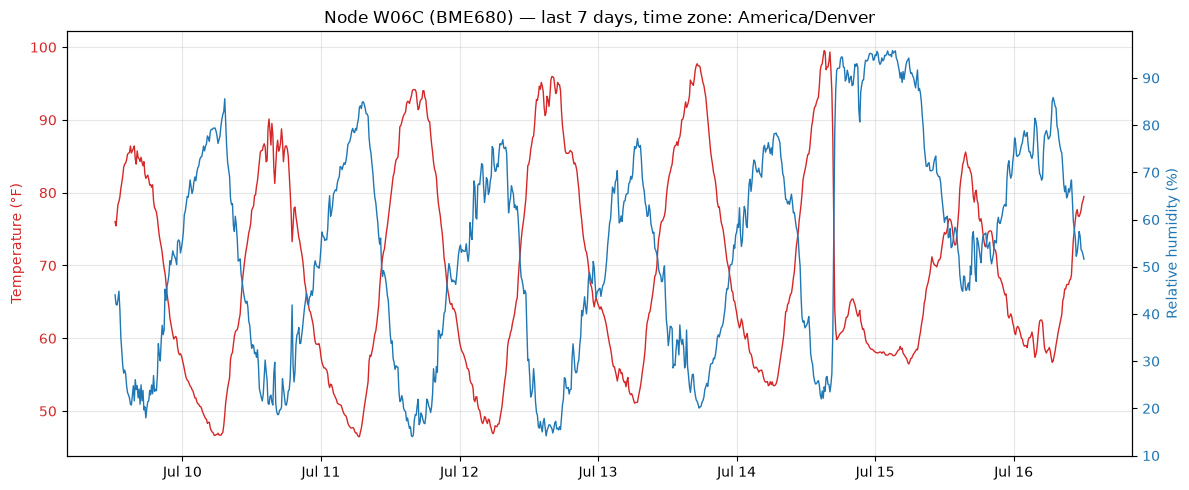

In [6]:
fig, ax_t = plt.subplots()

ax_t.plot(data.index, data["temp_F"], color="tab:red", lw=1)
ax_t.set_ylabel("Temperature (°F)", color="tab:red")
ax_t.tick_params(axis="y", labelcolor="tab:red")

ax_rh = ax_t.twinx()
ax_rh.plot(data.index, data["rh_pct"], color="tab:blue", lw=1)
ax_rh.set_ylabel("Relative humidity (%)", color="tab:blue")
ax_rh.tick_params(axis="y", labelcolor="tab:blue")
ax_rh.grid(False)

ax_t.set_title(f"Node W06C (BME680) — last 7 days, time zone: {data.index.tz}")
ax_t.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=data.index.tz))
plt.tight_layout()
plt.show()

The wiggles often match on shorter timescales too, a passing cloud or a cool gust shows up in both traces at once. Let's put a number on the relationship.

## 5. Quantifying the anti-correlation

Each dot below is one 10-minute average, colored by hour of day. The Pearson *r* measures how tightly the two variables are (inversely) linked, and the slope of the fit tells us how many percentage points of RH are lost per degree of warming *at this site, this week*.

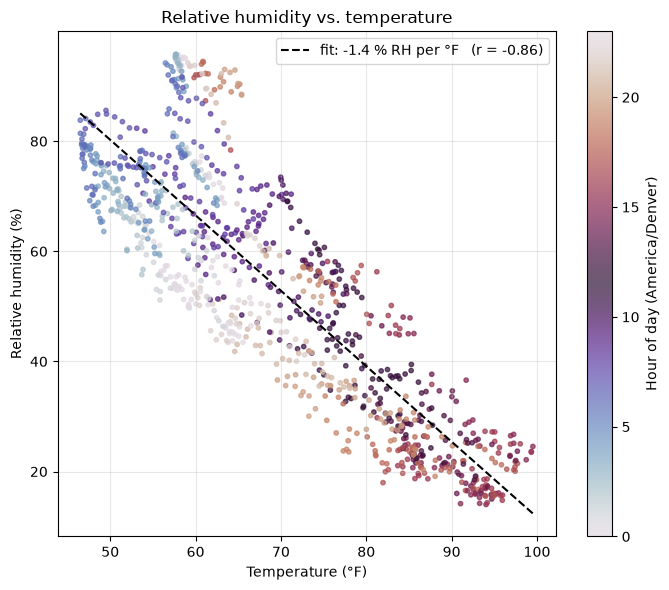

Pearson correlation: r = -0.856   (r² = 0.73)


In [7]:
r = data["temp_F"].corr(data["rh_pct"])

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    data["temp_F"], data["rh_pct"],
    c=data.index.hour, cmap="twilight", s=10, alpha=0.7,
)
fig.colorbar(sc, ax=ax, label=f"Hour of day ({data.index.tz})")

# Linear fit for reference
slope, intercept = np.polyfit(data["temp_F"], data["rh_pct"], 1)
xs = np.linspace(data["temp_F"].min(), data["temp_F"].max(), 100)
ax.plot(xs, slope * xs + intercept, "k--", lw=1.5,
        label=f"fit: {slope:.1f} % RH per °F   (r = {r:.2f})")

ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Relative humidity (%)")
ax.set_title("Relative humidity vs. temperature")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation: r = {r:.3f}   (r² = {r**2:.2f})")

For a fair-weather week, *r* typically lands between about −0.7 and −0.95. Notice the loops in the scatter: mornings and evenings trace slightly different paths at the same temperature. That hysteresis is a hint that temperature isn't the *whole* story; the moisture content drifts a little over the week too. More on that in section 8.

## 6. The average day

Averaging by hour of day compresses the whole week into one "typical" diurnal cycle. The two curves are almost perfectly out of phase: humidity peaks around dawn (the coolest hour) and bottoms out in mid-afternoon (the warmest).

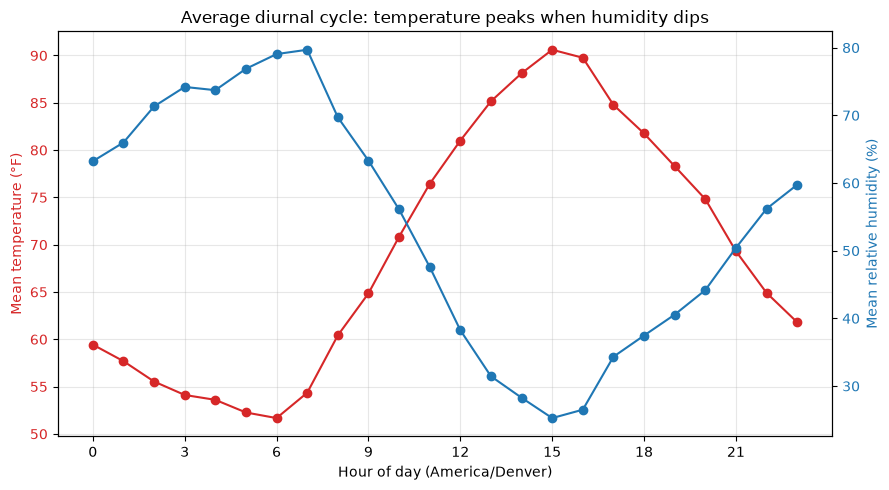

In [8]:
hourly = data.groupby(data.index.hour)[["temp_F", "rh_pct"]].mean()

fig, ax_t = plt.subplots(figsize=(9, 5))
ax_t.plot(hourly.index, hourly["temp_F"], "o-", color="tab:red")
ax_t.set_xlabel(f"Hour of day ({data.index.tz})")
ax_t.set_ylabel("Mean temperature (°F)", color="tab:red")
ax_t.tick_params(axis="y", labelcolor="tab:red")
ax_t.set_xticks(range(0, 24, 3))

ax_rh = ax_t.twinx()
ax_rh.plot(hourly.index, hourly["rh_pct"], "o-", color="tab:blue")
ax_rh.set_ylabel("Mean relative humidity (%)", color="tab:blue")
ax_rh.tick_params(axis="y", labelcolor="tab:blue")
ax_rh.grid(False)

ax_t.set_title("Average diurnal cycle: temperature peaks when humidity dips")
plt.tight_layout()
plt.show()

## 7. Why does warming *lower* relative humidity?

Relative humidity compares the water vapor that is **in** the air (vapor pressure $e$) with the most the air could hold at its current temperature  (the *saturation vapor pressure* $e_s(T)$), given by the Magnus formula (which takes $T$ in **°C**; the code converts from °F automatically):

$$
\mathrm{RH} \;=\; 100 \times \frac{e}{e_s(T)},
\qquad
e_s(T) \;\approx\; 6.112\, \exp\!\left(\frac{17.62\,T}{243.12+T}\right)\ \text{hPa}
$$

The crucial fact (the Clausius–Clapeyron relation, approximated above by the Magnus formula) is that $e_s$ grows **nearly exponentially** with temperature, roughly **4 % per °F** (7 % per °C). The numerator $e$ is set by how much water vapor is actually present and usually changes slowly, but the denominator $e_s(T)$ swings with every warm afternoon. Warm the air and RH drops; cool it and RH climbs, potentially all the way to fog or dew.

The plot below makes it concrete: take air that is saturated (100 % RH) at 50 °F and warm it to 86 °F **without adding or removing any water**, its relative humidity collapses to about 29 %.

*("Hold" is a convenient shorthand — strictly, $e_s$ is the equilibrium vapor pressure over liquid water, a property of temperature alone.)*

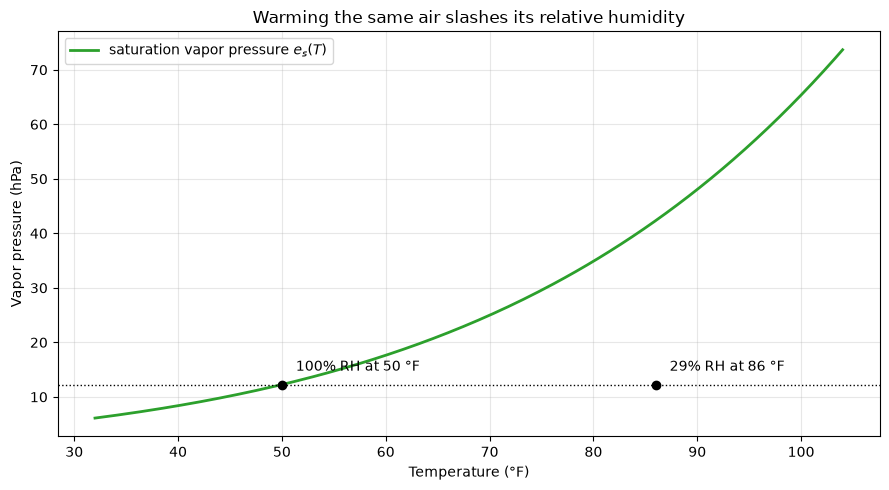

In [9]:
def f_to_c(T_f):
    """Convert °F to °C."""
    return (T_f - 32) * 5 / 9

def sat_vapor_pressure(T_f):
    """Saturation vapor pressure over water (hPa) from temperature in °F (Magnus)."""
    T_c = f_to_c(T_f)
    return 6.112 * np.exp(17.62 * T_c / (243.12 + T_c))

T = np.linspace(32, 104, 200)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T, sat_vapor_pressure(T), color="tab:green", lw=2,
        label="saturation vapor pressure $e_s(T)$")

# The same air parcel (same actual vapor pressure) at two temperatures
e_actual = sat_vapor_pressure(50)  # air that is saturated at 50 °F
for T_pt in (50, 86):
    rh_pt = 100 * e_actual / sat_vapor_pressure(T_pt)
    ax.scatter([T_pt], [e_actual], zorder=5, color="k")
    ax.annotate(f"{rh_pt:.0f}% RH at {T_pt} °F",
                (T_pt, e_actual), textcoords="offset points", xytext=(10, 10))
ax.axhline(e_actual, color="k", ls=":", lw=1)

ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Vapor pressure (hPa)")
ax.set_title("Warming the same air slashes its relative humidity")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 8. Dew point — tracking the moisture itself

The **dew point** $T_d$ is the temperature the air would need to be cooled to in order to reach saturation. It depends only on the actual moisture content, which makes it the perfect control experiment:

- If the daily RH swings were caused by **moisture** coming and going, the dew point would swing just as hard.
- If they're caused by **temperature**, the dew point should stay comparatively flat while temperature (and with it RH) oscillates.

We can invert the Magnus formula to get $T_d$ from our measured $T$ and RH.

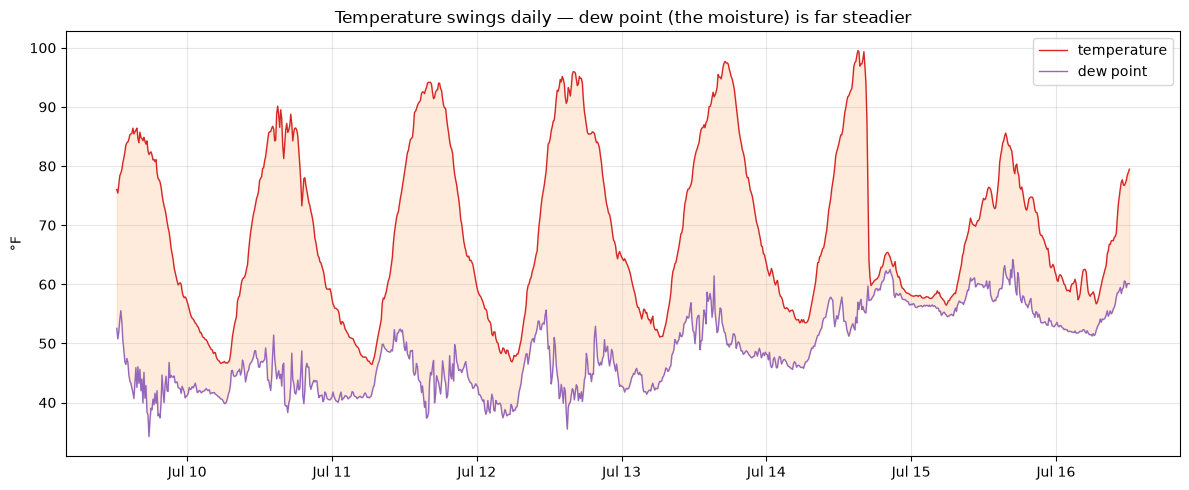

Correlation with temperature:
  relative humidity: r = -0.86
  dew point:         r = +0.17

Standard deviation over the week:
  temperature: 14.1 °F
  dew point:   6.5 °F


In [10]:
def dew_point(T_f, rh_pct):
    """Dew point (°F) from temperature (°F) and relative humidity (Magnus formula)."""
    a, b = 17.62, 243.12
    T_c = f_to_c(T_f)
    gamma = np.log(np.clip(rh_pct, 0.1, 100) / 100) + a * T_c / (b + T_c)
    return (b * gamma / (a - gamma)) * 9 / 5 + 32

data["dewpoint_F"] = dew_point(data["temp_F"], data["rh_pct"])

fig, ax = plt.subplots()
ax.plot(data.index, data["temp_F"], color="tab:red", lw=1, label="temperature")
ax.plot(data.index, data["dewpoint_F"], color="tab:purple", lw=1, label="dew point")
ax.fill_between(data.index, data["dewpoint_F"], data["temp_F"],
                color="tab:orange", alpha=0.15)
ax.set_ylabel("°F")
ax.set_title("Temperature swings daily — dew point (the moisture) is far steadier")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=data.index.tz))
plt.tight_layout()
plt.show()

print("Correlation with temperature:")
print(f"  relative humidity: r = {data['temp_F'].corr(data['rh_pct']):+.2f}")
print(f"  dew point:         r = {data['temp_F'].corr(data['dewpoint_F']):+.2f}")
print("\nStandard deviation over the week:")
print(f"  temperature: {data['temp_F'].std():.1f} °F")
print(f"  dew point:   {data['dewpoint_F'].std():.1f} °F")

The gap between the two curves (the *dew point depression*) is itself a dryness gauge: wide in the warm afternoons, narrow at night. When the curves touch, RH is 100 %, fog or dew territory. And where the dew point *does* shift or step, that marks a genuine change in moisture (a new air mass, rain), which is exactly what produced the loops in the scatter plot of section 5.

## 9. What we learned

1. **Temperature and relative humidity are strongly anti-correlated** at node W06C, both across the week and within the average day: RH peaks near dawn and bottoms out in mid-afternoon.
2. **The driver is physics, not coincidence.** Saturation vapor pressure $e_s(T)$ grows about 4 % per °F, so with roughly constant moisture, daytime warming mechanically deflates RH.
3. **Dew point isolates the moisture.** It stays comparatively steady day-to-day, confirming the RH swings are mostly temperature-driven; its slower drifts and steps mark real moisture changes (air masses, precipitation).

**Caveats worth remembering**

- The BME680 is mounted on the node itself, so absolute readings can be biased by enclosure and self-heating effects relative to a reference weather station. The *relationship* is robust; the absolute calibration may not be.
- The link isn't purely one-way: fronts and rain change the moisture ($e$) too watch the dew point for those events.

**References**
- [Sage documentation](https://docs.sagecontinuum.org) 
- [sage-data-client on PyPI](https://pypi.org/project/sage-data-client/) · 
- Alduchov & Eskridge (1996), *Improved Magnus form approximation of saturation vapor pressure* 